# KMeans

***
<img src="https://cdn.prod.website-files.com/62d9f09a3f988192955bafdd/6333e9332cf32e53dcac9bae_ANJpLrDpJp_RPPV1D0TnCmx6FMjZG2ygVBqbMZoXa_qGxyZ3EUz2Hv739N0MIto5nRu4vNMzTZ5DUtLeWhT4v6s4cUJ5bZtb-mBPiT7drbPJLLp8-R2LdD1k3IYgNYILuIGdrClbuCK6TuGKD22-AZFIsHswldYsAmrzwt248kLAKZu7t2MUVGoK.png" alt="Kmeans" width="250" />


O KMeans pertencem à classe de modelos não supervisionados. Modelos não supervisionados não requerem a utilização de classes, ou um alvo específico para aprender padrões. A partir das próprias features no dataset, os padrões são aprendidos.


In [19]:
!pip install ucimlrepo

In [20]:
# Bibliotecas de manipualção e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

# Classes do modelo
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

seed = 42

## Métodos para visualização

In [21]:
def show_decision_region(x, y, clf, f0, f1, centroids=None):
    plot_decision_regions(x, y, clf=clf)
    plt.xlabel(f0)
    plt.ylabel(f1)
    plt.title(clf.__class__.__name__)

    if centroids is not None:
        plt.scatter(
            centroids[:, 0],
            centroids[:, 1],
            c="tab:red",
            marker="*",
            s=300,
            alpha=1
        )
    plt.show()

## Conjunto de dados

In [22]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

dataset = pd.concat([X,y], axis=1)

In [23]:
dataset.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [24]:
# Vamos utilizar apenas duas features para facilitar a visualização
feature_0 = "petal length"
feature_1 = "petal width"

X = dataset.iloc[:,[2,3]]

# Não vamos considerar y, porque o k-means é não supervisionado
# y = dataset.iloc[:,[4]]

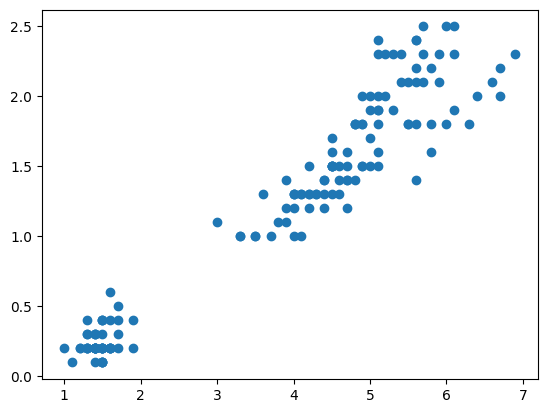

In [25]:
plt.scatter(
    X[feature_0],
    X[feature_1],
)

## k-means

O k-Means requer que você informe a quantidade de centróides em que os dados devem ser agrupados. Cada centróides representa o ponto de referência para um cluster.

Alguns pontos que devem ser observados:

- Inicialmente, um centróide pode ser escolhido como uma instância aleatória do dataset, que será atualizado até a variação do ponto durante sua atualização se tornar baixa o suficiente.

    _No sklearn_: Implementa otimizações sobre o algoritmo original. A escolha inicial dos centróides não é feita de forma puramente aleatória, utiliza o algoritmo k-means++, no qual a probabilidade de escolher um ponto respeita uma função de distribuição não-linear. A cada vez que uma instância é escolhida, a probabilidade de escolher uma nova instância próxima às anteriores é menor.

- Após os clusters atingirem convergência, o algoritmo termina sua execução.

    _No sklearn_: o algoritmo é executado várias vezes (10 por padrão), e o resultado com melhor clusterização é utilizado.

In [26]:
model = KMeans(n_clusters=3, random_state=seed)

# No fit pode ser passado o y, mas ele não é usado, presente apenas para consistência da API por convenção.
model.fit(X)
cluster_pred = model.predict(X)
cluster_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

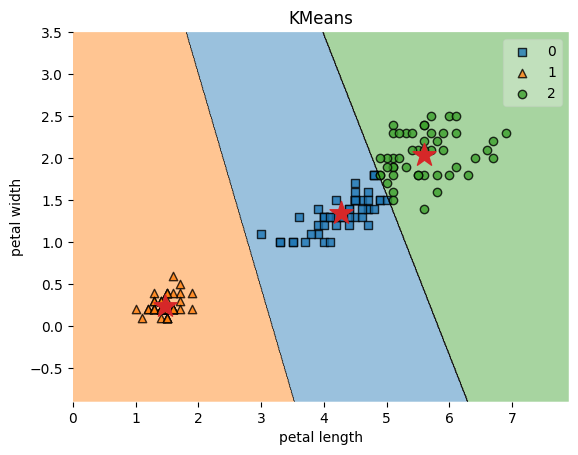

In [27]:
show_decision_region(
    np.array(
        [
            X[feature_0].values,
            X[feature_1].values,
        ]
    ).T,
    cluster_pred,
    model,
    feature_0,
    feature_1,
    model.cluster_centers_
)

Note que a custerização cria uma região linear!

---------------------------


### Existe algum método para definir a quantidade ideal de agrupamentos?

Existem duas métricas principais que precisamos conhecer ao lidar com o K-Means:

- **Inércia**: A soma das distâncias ao quadrado de todos os pontos de dados até o centróide. Na interpretação do valor da inércia, geralmente, quanto menor a inércia, melhor, pois essa métrica mede o quão próximos os pontos de dados estão de seus centróides.

- **Silhouette**: É uma métrica que indica quanto de sobreposição existe entre os clusters. Em outras palavras, ela calcula a distância de cada cluster em relação aos outros. Essa métrica varia entre -1 e 1, e quanto mais próxima de 1, menor é a sobreposição.



O método cotovelo ([**Elbow Method**](https://www.scikit-yb.org/en/latest/api/cluster/elbow.html)) usa a **inércia**.

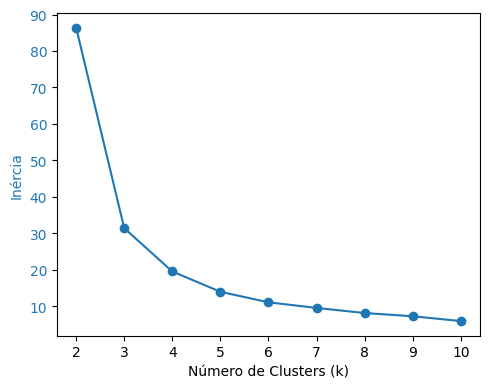

In [28]:

from sklearn.metrics import silhouette_score

# Listas para armazenar os valores de inércia e silhueta para cada k
inertia_values = []
silhouette_values = []

# Intervalo de valores de k para testar
k_values = range(2, 11)  # Começa em 2 porque silhueta não é definido para k=1

for k in k_values:
    model = KMeans(n_clusters=k, random_state=199)
    model.fit(X)

    # Calculando inércia
    inertia_values.append(model.inertia_)

    # Calculando coeficiente de silhueta
    # cluster_labels = model.predict(X)
    # silhouette_avg = silhouette_score(X, cluster_labels)
    # silhouette_values.append(silhouette_avg)

fig, ax1 = plt.subplots(figsize=(5, 4))

ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia', color='tab:blue')
ax1.plot(k_values, inertia_values, marker='o', color='tab:blue', label='Inércia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Coeficiente de Silhueta
# ax2 = ax1.twinx()
# ax2.set_ylabel('Coeficiente de Silhueta', color='tab:orange')
# ax2.plot(k_values, silhouette_values, marker='o', color='tab:orange', label='Silhueta')
# ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.show()

----------------------

## Limitações do K-means

No exemplo anterior, observamos que a região criada pelo KMeans é linear. Isso é referente ao KMeans ou ao dataset? Vamos avaliar outro dataset.

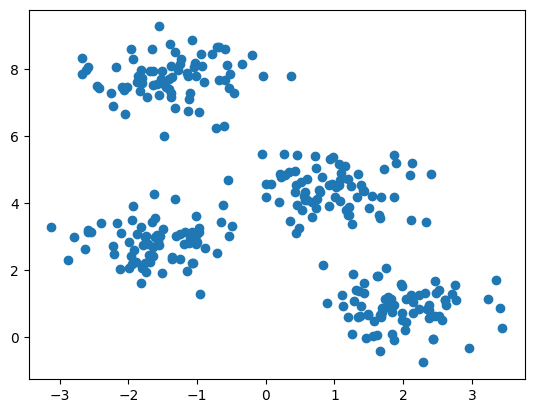

In [29]:
from sklearn.datasets import make_blobs, make_circles

# criação do dataset
X_b, _ = make_blobs(300, 2, centers=4, cluster_std=0.6, random_state=0)
plt.scatter(X_b[:, 0], X_b[:, 1])

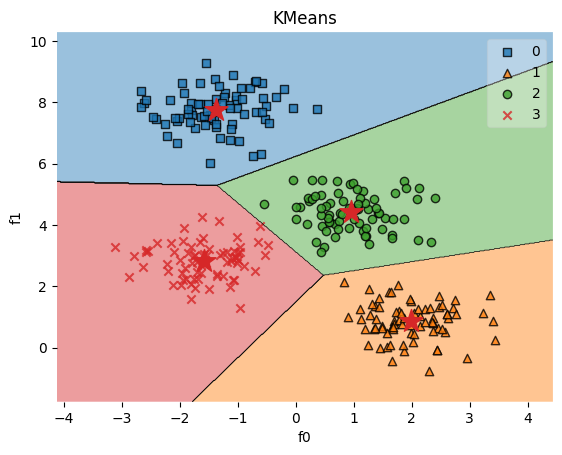

In [30]:
model = KMeans(n_clusters=4)
model.fit(X_b)
cluster_pred_b = model.predict(X_b)

show_decision_region(
    X_b,
    cluster_pred_b,
    model,
    "f0",
    "f1",
    model.cluster_centers_
)

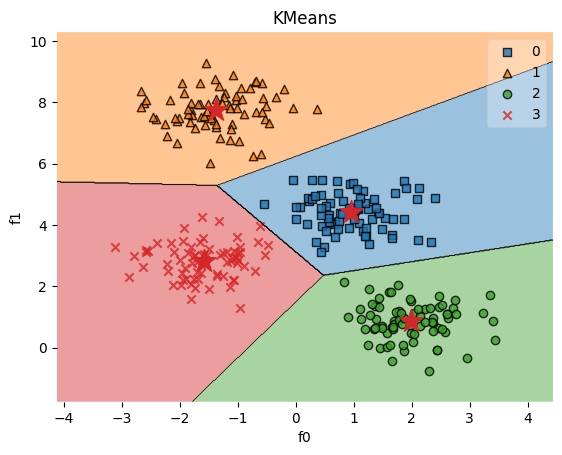

In [31]:
# E se removermos a otimização do k-means

model = KMeans(n_clusters=4, init="random", n_init=1, random_state=0)
model.fit(X_b)
cluster_pred_b = model.predict(X_b)

show_decision_region(
    X_b,
    cluster_pred_b,
    model,
    "f0",
    "f1",
    model.cluster_centers_
)

**Vamos observar outro exemplo**

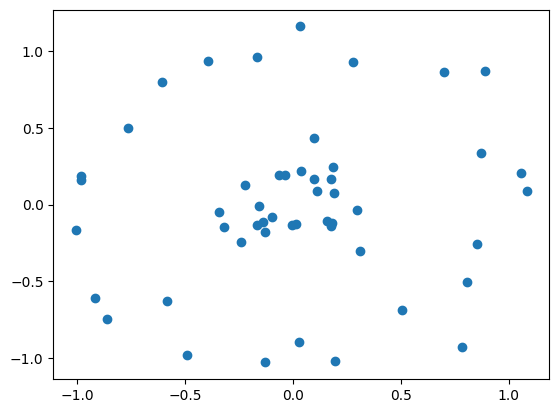

In [32]:
X_c, _ = make_circles(n_samples=50, noise=0.1, random_state=199, factor=0.2)
plt.scatter(X_c[:, 0], X_c[:, 1])

Esse dataset possui uma não-linearidade, será que o KMeans consegue resolver essa região?

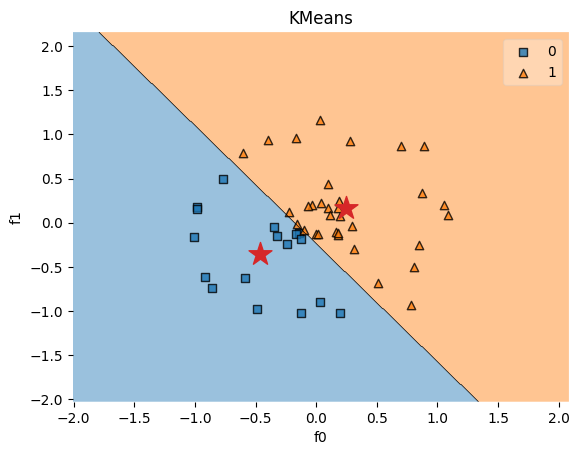

In [33]:
model = KMeans(n_clusters=2)
model.fit(X_c)
cluster_pred_c = model.predict(X_c)

show_decision_region(
    X_c,
    cluster_pred_c,
    model,
    "f0",
    "f1",
    model.cluster_centers_
)

Aqui observamos que KMeans não consegue capturar grupamentos não lineares de forma eficiente. Observe que para atribuir uma instância a um cluster, o KMeans utiliza distância euclidiana, portanto, criando regiões de separação lineares.


Encontre mais informações [aqui](https://scikit-learn.org/stable/modules/clustering.html)

------------------------------
<a href="https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png" target="_blank">
    <img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png" alt="Clustering" style="width:1000px;"/>
</a>

## DBSCAN

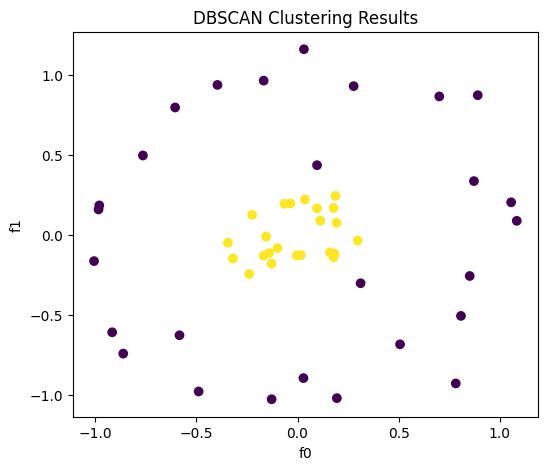

In [34]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.2, min_samples=5) # Added parameters for better clustering
model.fit(X_c)
#cluster_pred_c = model.predict(X_c) # Removed the predict call

plt.figure(figsize=(6, 5))
plt.scatter(X_c[:, 0], X_c[:, 1], c=[model.labels_], cmap='viridis')
plt.title('DBSCAN Clustering Results')
plt.xlabel('f0')
plt.ylabel('f1')
plt.show()